<a href="https://colab.research.google.com/github/exdsgift/NerGuard/blob/main/PII_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing the modules

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"

In [2]:
# !pip install -q "transformers>=4.40" datasets seqeval accelerate

import torch
import os, json, unicodedata
from datasets import load_dataset, DatasetDict
import numpy as np
from typing import List, Dict, Tuple
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
from seqeval.metrics import f1_score, classification_report
from seqeval.scheme import IOB2
import pprint as pp

2025-10-19 16:26:41.204812: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Specifying CUDA as the device for torch

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
!nvidia-smi

Sun Oct 19 16:26:44 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.230.02             Driver Version: 535.230.02   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Quadro RTX 6000                On  | 00000000:19:00.0 Off |                  Off |
| 33%   31C    P8              31W / 260W |   9415MiB / 24576MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

# Loading dataset

In [4]:
ds = load_dataset("gretelai/synthetic_pii_finance_multilingual")
print(ds)

DatasetDict({
    train: Dataset({
        features: ['level_0', 'index', 'document_type', 'document_description', 'expanded_type', 'expanded_description', 'language', 'language_description', 'domain', 'generated_text', 'pii_spans', 'conformance_score', 'quality_score', 'toxicity_score', 'bias_score', 'groundedness_score'],
        num_rows: 50346
    })
    test: Dataset({
        features: ['level_0', 'index', 'document_type', 'document_description', 'expanded_type', 'expanded_description', 'language', 'language_description', 'domain', 'generated_text', 'pii_spans', 'conformance_score', 'quality_score', 'toxicity_score', 'bias_score', 'groundedness_score'],
        num_rows: 5594
    })
})


In [5]:
if "validation" not in ds:
    tmp = ds["train"].train_test_split(test_size=0.1, seed=42)
    ds = DatasetDict({
        "train": tmp["train"],
        "validation": tmp["test"],
        "test": ds["test"]
    })
print(ds)

DatasetDict({
    train: Dataset({
        features: ['level_0', 'index', 'document_type', 'document_description', 'expanded_type', 'expanded_description', 'language', 'language_description', 'domain', 'generated_text', 'pii_spans', 'conformance_score', 'quality_score', 'toxicity_score', 'bias_score', 'groundedness_score'],
        num_rows: 45311
    })
    validation: Dataset({
        features: ['level_0', 'index', 'document_type', 'document_description', 'expanded_type', 'expanded_description', 'language', 'language_description', 'domain', 'generated_text', 'pii_spans', 'conformance_score', 'quality_score', 'toxicity_score', 'bias_score', 'groundedness_score'],
        num_rows: 5035
    })
    test: Dataset({
        features: ['level_0', 'index', 'document_type', 'document_description', 'expanded_type', 'expanded_description', 'language', 'language_description', 'domain', 'generated_text', 'pii_spans', 'conformance_score', 'quality_score', 'toxicity_score', 'bias_score', 'grounde

In [6]:
ds.shape

{'train': (45311, 16), 'validation': (5035, 16), 'test': (5594, 16)}

In [7]:
df = ds["train"].to_pandas()
df.head()

,level_0,index,document_type,document_description,expanded_type,expanded_description,language,language_description,domain,generated_text,pii_spans,conformance_score,quality_score,toxicity_score,bias_score,groundedness_score
0,14276,14276,Email,A communication document typically containing ...,Marketing,Craft an email for a new product launch target...,English,English language as spoken in the United Kingdom,finance,Subject: Introducing Our Innovative Product - ...,"[{""start"": 68, ""end"": 94, ""label"": ""name""}, {""...",85,90,5,15,95
1,14112,14112,Mortgage Amortization Schedule,A table detailing the repayment schedule of a ...,FHA Loan,Develop a subtype with flexible qualification ...,Swedish,Swedish language as spoken in Sweden,finance,| Betalningsdatum | Belopp | Ränta | Kapital |...,"[{""start"": 20, ""end"": 26, ""label"": ""name""}, {""...",95,85,5,10,90
2,13679,13679,Financial Forecast,A projection of future financial outcomes for ...,Financial Fraud Detection,"For a synthetic Financial Fraud Detection, uti...",France,French language as spoken in France,finance,Prévision Financière - Détection de Fraude Fin...,"[{""start"": 68, ""end"": 86, ""label"": ""name""}, {""...",85,90,5,10,95
3,27424,27424,Policyholder's Report,A report provided to the policyholder detailin...,Loss Prevention Tips,Develop a set of practical tips and recommenda...,France,French language as spoken in France,finance,Rapport de Prévention des Sinistres\n\nChère M...,"[{""start"": 43, ""end"": 67, ""label"": ""name""}, {""...",85,90,5,15,95
4,40189,40189,Investment Prospectus,"A formal document detailing the objectives, ri...",Small Business Loan,Create a guide for assessing small business lo...,English,English language as spoken in the United State...,finance,INVESTMENT PROSPECTUS\n\nIntroducing an Exciti...,"[{""start"": 84, ""end"": 101, ""label"": ""name""}, {...",95,85,5,15,90


# Activating the mdeberta-v3-base tokenizer (fast) and support functions

In [8]:
try:
  tok = AutoTokenizer.from_pretrained("microsoft/mdeberta-v3-base", use_fast=True)
  assert tok.is_fast, "Serve tokenizer fast per offset_mapping"
except Exception as e:
  print("An error occurred while downloading the tokenizer.")
  print(str(e))
  import traceback
  print(traceback.format_exc())

/home/gabriele/Github/NerGuard/.venv/lib/python3.11/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [9]:
def parse_spans(spans):
    if isinstance(spans, str):
        try:
            spans = json.loads(spans)
        except json.JSONDecodeError:
            return []
    if not isinstance(spans, list):
        return []
    out = []
    for s in spans:
        if isinstance(s, dict) and all(k in s for k in ("start","end","label")):
            out.append(s)
    return out

In [10]:
def collect_label_set(dataset_dict):
    labels = set()
    for split in dataset_dict.keys():
        for ex in dataset_dict[split]:
            for s in parse_spans(ex["pii_spans"]):
                labels.add(s["label"])
    return sorted(labels)

entity_labels = collect_label_set(ds)  # es: ['company','date','name','street_address', ...]
bio_labels = ["O"] + [f"B-{l}" for l in entity_labels] + [f"I-{l}" for l in entity_labels]
label2id = {l:i for i,l in enumerate(bio_labels)}
id2label = {i:l for l,i in label2id.items()}

In [11]:
bio_labels

['O',
 'B-account_pin',
 'B-api_key',
 'B-bank_routing_number',
 'B-bban',
 'B-company',
 'B-credit_card_number',
 'B-credit_card_security_code',
 'B-customer_id',
 'B-date',
 'B-date_of_birth',
 'B-date_time',
 'B-driver_license_number',
 'B-email',
 'B-employee_id',
 'B-first_name',
 'B-iban',
 'B-ipv4',
 'B-ipv6',
 'B-last_name',
 'B-local_latlng',
 'B-name',
 'B-passport_number',
 'B-password',
 'B-phone_number',
 'B-ssn',
 'B-street_address',
 'B-swift_bic_code',
 'B-time',
 'B-user_name',
 'I-account_pin',
 'I-api_key',
 'I-bank_routing_number',
 'I-bban',
 'I-company',
 'I-credit_card_number',
 'I-credit_card_security_code',
 'I-customer_id',
 'I-date',
 'I-date_of_birth',
 'I-date_time',
 'I-driver_license_number',
 'I-email',
 'I-employee_id',
 'I-first_name',
 'I-iban',
 'I-ipv4',
 'I-ipv6',
 'I-last_name',
 'I-local_latlng',
 'I-name',
 'I-passport_number',
 'I-password',
 'I-phone_number',
 'I-ssn',
 'I-street_address',
 'I-swift_bic_code',
 'I-time',
 'I-user_name']

spans → BIO with offset_mapping

In [12]:
def spans_to_bio(text, spans, label2id, tokenizer, max_length=256):
    import unicodedata
    text = unicodedata.normalize("NFC", text)
    spans = parse_spans(spans)

    # 1) maschera char-level
    char_tags = ["O"] * len(text)
    for s in spans:
        start, end, lab = s.get("start"), s.get("end"), s.get("label")
        if not isinstance(start,int) or not isinstance(end,int) or not isinstance(lab,str):
            continue
        if start < 0 or end <= start or end > len(text):
            continue
        if f"B-{lab}" not in label2id or f"I-{lab}" not in label2id:
            continue
        char_tags[start] = f"B-{lab}"
        for i in range(start+1, end):
            char_tags[i] = f"I-{lab}"

    # 2) tokenizza con special e offsets
    enc = tokenizer(
        text,
        return_offsets_mapping=True,
        return_attention_mask=True,
        add_special_tokens=True,     # <-- importante
        truncation=True,
        max_length=max_length
    )
    offsets = enc["offset_mapping"]

    tags = []
    for (a, b) in offsets:
        if a == 0 and b == 0:
            tags.append(None)        # special token -> ignora in loss
            continue
        if a == b:
            tags.append("O")
            continue
        start_tag = char_tags[a] if 0 <= a < len(text) else "O"
        if start_tag.startswith("B-"):
            lab = start_tag
        else:
            window = [t for t in char_tags[a:b] if t != "O"]
            if window:
                any_lab = window[0]
                lab = "I-" + any_lab.split("-", 1)[1]
            else:
                lab = "O"
        tags.append(lab)

    ignore_index = -100
    label_ids = [ignore_index if t is None else label2id[t] for t in tags]
    return enc["input_ids"], enc["attention_mask"], label_ids


Processing all splits

In [13]:
from transformers import DataCollatorForTokenClassification

TEXT_COL = "generated_text"
SPAN_COL = "pii_spans"

def preprocess_batch(batch):
    input_ids, attention_mask, labels = [], [], []
    for text, spans in zip(batch[TEXT_COL], batch[SPAN_COL]):
        ids, mask, y = spans_to_bio(text, spans, label2id, tok, max_length=256)
        input_ids.append(ids); attention_mask.append(mask); labels.append(y)
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

remove_cols = list(ds["train"].column_names)
processed = DatasetDict()
for split in ds.keys():
    processed[split] = ds[split].map(
        preprocess_batch,
        batched=True,
        remove_columns=remove_cols
    ).with_format("torch",
                  columns=["input_ids","attention_mask"],
                  output_all_columns=True)

#.with_format("torch", columns=["input_ids","attention_mask","labels"])
train_processed = processed["train"]
val_processed   = processed["validation"]

data_collator = DataCollatorForTokenClassification(
    tokenizer=tok,
    padding=True,
    label_pad_token_id=-100
)

In [14]:
ds = train_processed.to_pandas()
ds.head(3)

,input_ids,attention_mask,labels
0,"[1, 44566, 268, 92174, 348, 7469, 337, 192623,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[1, 308, 182073, 1010, 123694, 308, 1072, 5143...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 0, 0, 0, 0, 0, 50, 50, 0, 0, 0, 0, 0, 0..."
2,"[1, 34682, 24745, 68313, 5521, 260, 265, 7981,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [15]:
print(train_processed[0])

{'input_ids': tensor([     1,  44566,    268,  92174,    348,   7469,    337, 192623,  11554,
           260,    265,   5660,    278,    271,  13859,   7733,    310,    460,
           373,   6977,   7722,   1980,    260,  56024,  14599,    262,   1307,
         10149,    715,   5564,   3535,    264,    522,   2858,    261,   1307,
           419,  21102,    346,    289,    260, 103110,    288,  27398,    305,
          1407,  28318,  58811,   5690,    262,    306,    788,    260,  14038,
           522,    899,   3535,    610,  34456,   1060,    261,   7469,   1547,
          5690,    340,    260,  24226,    289,   2150,    773,   4257,    260,
           266,  46909,    306,   1098,  42425,    261,   3127,   2477,    260,
         39261,  14182,    306,    260,  66128,    265,  35528,  16186,    262,
           610,    340,   7780,    289, 116337,    773,    260,  88484,    264,
           261,   1307,    419,  92538,    534,    522,    899,   3535,    610,
           289,    391,   

In [16]:
from pprint import pprint

print("num_labels:", len(label2id))
pprint(label2id)           # label string -> id
# If you also want the reverse:
id2label = {i:l for l,i in label2id.items()}


num_labels: 59
{'B-account_pin': 1,
 'B-api_key': 2,
 'B-bank_routing_number': 3,
 'B-bban': 4,
 'B-company': 5,
 'B-credit_card_number': 6,
 'B-credit_card_security_code': 7,
 'B-customer_id': 8,
 'B-date': 9,
 'B-date_of_birth': 10,
 'B-date_time': 11,
 'B-driver_license_number': 12,
 'B-email': 13,
 'B-employee_id': 14,
 'B-first_name': 15,
 'B-iban': 16,
 'B-ipv4': 17,
 'B-ipv6': 18,
 'B-last_name': 19,
 'B-local_latlng': 20,
 'B-name': 21,
 'B-passport_number': 22,
 'B-password': 23,
 'B-phone_number': 24,
 'B-ssn': 25,
 'B-street_address': 26,
 'B-swift_bic_code': 27,
 'B-time': 28,
 'B-user_name': 29,
 'I-account_pin': 30,
 'I-api_key': 31,
 'I-bank_routing_number': 32,
 'I-bban': 33,
 'I-company': 34,
 'I-credit_card_number': 35,
 'I-credit_card_security_code': 36,
 'I-customer_id': 37,
 'I-date': 38,
 'I-date_of_birth': 39,
 'I-date_time': 40,
 'I-driver_license_number': 41,
 'I-email': 42,
 'I-employee_id': 43,
 'I-first_name': 44,
 'I-iban': 45,
 'I-ipv4': 46,
 'I-ipv6': 47,

In [17]:
# take one example from the processed train set
ex = train_processed[0]

tokens = tok.convert_ids_to_tokens(ex["input_ids"])
tag_ids = ex["labels"]
tag_str = [id2label[int(i)] for i in tag_ids if i != -100]
aligned_data = [(tokens[i], tag_ids[i], id2label[int(tag_ids[i])]) for i in range(len(tokens)) if tag_ids[i] != -100]

for t, tid, ts in aligned_data:
    print(f"{t:20s}  {tid:3d}  {ts}")

▁Subject                0  O
:                       0  O
▁Introduc               0  O
ing                     0  O
▁Our                    0  O
▁I                      0  O
nnovative               0  O
▁Product                0  O
▁                       0  O
-                       0  O
▁Don                    0  O
'                       0  O
t                       0  O
▁Miss                   0  O
▁Out                    0  O
!                       0  O
▁De                     0  O
ar                      0  O
▁Ana                   50  I-name
▁Bel                   50  I-name
én                     50  I-name
▁                      50  I-name
Javier                 50  I-name
▁Francisco             50  I-name
,                       0  O
▁We                     0  O
▁hope                   0  O
▁this                   0  O
▁email                  0  O
▁find                   0  O
s                       0  O
▁you                    0  O
▁well                   0  O
.            

# Selecting a batch size and creating an iterator

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from keras.utils import pad_sequences
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertConfig
from torch.optim import AdamW
from transformers.optimization import get_linear_schedule_with_warmup
from transformers import BertForSequenceClassification
from tqdm import tqdm, trange  #for progress bars
import pandas as pd
import io
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image #for image rendering

In [19]:
train_processed

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 45311
})

In [20]:
# Select a batch size for training. For fine-tuning BERT on a specific task, the authors recommend a batch size of 16 or 32
batch_size = 32

# Create an iterator of our data with torch DataLoader. This helps save on memory during training because, unlike a for loop,
# with an iterator the entire dataset does not need to be loaded into memory

# train_data = TensorDataset(train_processed['input_ids'], train_processed['attention_mask'], train_processed['labels'])
train_sampler = RandomSampler(train_processed)
train_dataloader = DataLoader(train_processed, sampler=train_sampler, batch_size=batch_size, collate_fn=data_collator)

# validation_data = TensorDataset(val_processed)
validation_sampler = SequentialSampler(val_processed)
validation_dataloader = DataLoader(val_processed, sampler=validation_sampler, batch_size=batch_size, collate_fn=data_collator)


In [21]:
# Initializing a BERT bert-base-uncased style configuration
from transformers import AutoConfig, AutoModel, AutoTokenizer
model_name = "microsoft/deberta-v3-base"

configuration = AutoConfig.from_pretrained(model_name)

# Initializing a model from the bert-base-uncased style configuration
model = AutoModel.from_pretrained(model_name, config=configuration)

# Accessing the model configuration
# configuration = model.config
print(configuration)

DebertaV2Config {
  "attention_probs_dropout_prob": 0.1,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-07,
  "legacy": true,
  "max_position_embeddings": 512,
  "max_relative_positions": -1,
  "model_type": "deberta-v2",
  "norm_rel_ebd": "layer_norm",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_dropout": 0,
  "pooler_hidden_act": "gelu",
  "pooler_hidden_size": 768,
  "pos_att_type": [
    "p2c",
    "c2p"
  ],
  "position_biased_input": false,
  "position_buckets": 256,
  "relative_attention": true,
  "share_att_key": true,
  "transformers_version": "4.57.0",
  "type_vocab_size": 0,
  "vocab_size": 128100
}



In [22]:
# @title
from collections import Counter

used_ids = Counter()
for example in train_processed:
    used_ids.update(i for i in example["labels"] if i != -100)   # ignore masked

print("Unique label IDs used:", len(used_ids))
for lid, cnt in used_ids.most_common()[:30]:
    print(f"{lid:3d}  {id2label[lid]:30s}  {cnt}")

Unique label IDs used: 59
  0  O                               9544131
 50  I-name                          252222
 55  I-street_address                243127
 34  I-company                       159738
 38  I-date                          153996
 42  I-email                         65821
 53  I-phone_number                  29110
 57  I-time                          25594
 21  B-name                          21394
 47  I-ipv6                          18319
  5  B-company                       16472
 31  I-api_key                       15440
 45  I-iban                          10552
 26  B-street_address                8352
 13  B-email                         6765
  9  B-date                          6728
 33  I-bban                          6443
 56  I-swift_bic_code                6369
 37  I-customer_id                   6221
 39  I-date_of_birth                 5591
 52  I-password                      5000
 49  I-local_latlng                  4831
 35  I-credit_card_number      

In [23]:
model = AutoModelForTokenClassification.from_pretrained(
    "microsoft/mdeberta-v3-base",
    num_labels=len(bio_labels),
    id2label=id2label,
    label2id=label2id
)

Some weights of DebertaV2ForTokenClassification were not initialized from the model checkpoint at microsoft/mdeberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
# RESIZE embeddings per matchare il tokenizer
print(f"Original vocab size: {model.config.vocab_size}")
model.resize_token_embeddings(len(tok))
print(f"Resized to: {model.config.vocab_size}")
print(f"Embeddings shape: {model.deberta.embeddings.word_embeddings.num_embeddings}")

Original vocab size: 251000
Resized to: 250102
Embeddings shape: 250102


In [25]:
model = nn.DataParallel(model, device_ids=[0, 1])
model = model.to(device)

In [ ]:
# Test con un batch su GPU
print("\n🧪 Testing forward pass...")
test_batch = next(iter(train_dataloader))

try:
    # Sposta su GPU
    test_input = test_batch['input_ids'][:2].to(device)
    test_mask = test_batch['attention_mask'][:2].to(device)
    test_labels = test_batch['labels'][:2].to(device)
    
    # Forward pass
    with torch.no_grad():
        outputs = model(test_input, attention_mask=test_mask, labels=test_labels)
    
    print("✓ Forward pass successful!")
    print(f"  Loss: {outputs.loss.mean().item():.4f}")
    print(f"  Logits shape: {outputs.logits.shape}")
    print(f"  Loss per GPU: {outputs.loss}")
    
except Exception as e:
    print(f"✗ Error: {e}")
    import traceback
    traceback.print_exc()


🧪 Testing forward pass...
✓ Forward pass successful!
  Loss: 4.5231
  Logits shape: torch.Size([2, 256, 59])
  Loss per GPU: tensor([4.5784, 4.4678], device='cuda:0')


In [28]:
# Parametri ottimizzati per DaBERTa v3 su task di NER/PII detection
param_optimizer = list(model.named_parameters())

# Non applicare weight decay a bias e LayerNorm
no_decay = ['bias', 'LayerNorm.weight', 'LayerNorm.bias']

optimizer_grouped_parameters = [
    {
        'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
        'weight_decay': 0.01  # Valore tipico per DaBERTa (0.01-0.1)
    },
    {
        'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0
    }
]

In [29]:
# Displaying a sample of the parameter_optimizer:  layer 3
layer_parameters = [p for n, p in model.named_parameters() if 'layer.3' in n]

In [30]:
# Displaying names of parameters for which weight decay is not applied
no_decay

['bias', 'LayerNorm.weight', 'LayerNorm.bias']

In [31]:
# Displaying the list of the two dictionaries
small_sample = [
    {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)][:2],
     'weight_decay_rate': 0.01},
    {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)][:2],
     'weight_decay_rate': 0.0}
]

for i, group in enumerate(small_sample):
    print(f"Group {i+1}:")
    print(f"Weight decay rate: {group['weight_decay_rate']}")
    for j, param in enumerate(group['params']):
        print(f"Parameter {j+1}: {param}")

Group 1:
Weight decay rate: 0.01
Parameter 1: Parameter containing:
tensor([[ 0.0187, -0.0047, -0.0024,  ..., -0.0198,  0.0154,  0.0246],
        [-0.0253, -0.0084, -0.0109,  ..., -0.0201, -0.0056, -0.0047],
        [-0.0233, -0.0060, -0.0109,  ..., -0.0165, -0.0049, -0.0019],
        ...,
        [ 0.0183, -0.0022, -0.0049,  ..., -0.0109,  0.0163,  0.0164],
        [ 0.0156,  0.0029, -0.0050,  ..., -0.0215,  0.0150,  0.0230],
        [-0.0560,  0.0241,  0.0872,  ...,  0.0065, -0.0975,  0.0826]],
       device='cuda:0', requires_grad=True)
Parameter 2: Parameter containing:
tensor([[ 0.0612, -0.1571,  0.1099,  ...,  0.0766, -0.1010, -0.0101],
        [-0.0350,  0.2230,  0.1971,  ...,  0.0668,  0.1351, -0.0952],
        [ 0.0621,  0.1041,  0.1530,  ..., -0.2688, -0.0279, -0.0012],
        ...,
        [ 0.2539,  0.0209,  0.0380,  ...,  0.1475,  0.0853,  0.0164],
        [-0.1096,  0.1230,  0.1782,  ...,  0.0779, -0.0202,  0.0695],
        [-0.1597,  0.1494,  0.2402,  ...,  0.1786, -0.02

#The hyperparameters for the training loop

In [32]:
# Number of training epochs (authors recommend between 2 and 4)
epochs = 4

optimizer = AdamW(optimizer_grouped_parameters,
                  lr = 2e-5, # args.learning_rate - default range: 1e-5 a 5e-5
                  eps = 1e-8 # args.adam_epsilon  - default is 1e-8.
                  )
# Total number of training steps is number of batches * number of epochs.
# `train_dataloader` contains batched data so `len(train_dataloader)` gives
# us the number of batches.
total_steps = len(train_dataloader) * epochs

# Create the learning rate scheduler.
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps = 0, # Default value in run_glue.py
                                            num_training_steps = total_steps)

In [33]:
# Creating the Accuracy Measurement Function
# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def compute_metrics(preds, labels, label_list):
    """
    Metrics for PII detection (precision, recall, F1)
    """
    pred_flat = np.argmax(preds, axis=2).flatten()
    labels_flat = labels.flatten()

    # Rimuovi i padding tokens (assumendo che -100 sia usato per padding)
    mask = labels_flat != -100
    pred_flat = pred_flat[mask]
    labels_flat = labels_flat[mask]

    # F1 score (più importante dell'accuracy per PII detection!)
    f1 = f1_score(labels_flat, pred_flat, average='weighted')
    accuracy = np.sum(pred_flat == labels_flat) / len(labels_flat)

    return {
        'accuracy': accuracy,
        'f1': f1
    }

# training loop

In [34]:
# ============== DIAGNOSTIC CODE ==============
print("Checking data integrity...")

# Check a sample batch
sample_batch = next(iter(train_dataloader))
print(f"Batch keys: {sample_batch.keys()}")
print(f"Input IDs shape: {sample_batch['input_ids'].shape}")
print(f"Labels shape: {sample_batch['labels'].shape}")

# Check label range
all_labels = []
for batch in train_dataloader:
    labels = batch['labels'].numpy()
    # Ignore padding (-100)
    valid_labels = labels[labels != -100]
    all_labels.extend(valid_labels.tolist())

all_labels = np.array(all_labels)
print(f"\nLabel Statistics:")
print(f"  Min label: {all_labels.min()}")
print(f"  Max label: {all_labels.max()}")
print(f"  Unique labels: {np.unique(all_labels)}")
print(f"  Model num_labels: {len(label2id)}")

# Check if labels are in valid range
if all_labels.max() >= len(label2id):
    print(f"\n⚠️ ERROR: Max label ({all_labels.max()}) >= num_labels ({len(label2id)})")
    print("Your labels are out of range!")
if all_labels.min() < 0:
    print(f"\n⚠️ WARNING: Found negative labels other than -100: {all_labels[all_labels < 0]}")

print("="*50 + "\n")

Checking data integrity...
Batch keys: KeysView({'input_ids': tensor([[     1,  53580,  84884,  ..., 107889,    305,      2],
        [     1,  13768,    305,  ...,    333,  30626,      2],
        [     1,  69910,  23810,  ...,    264,    507,      2],
        ...,
        [     1,  14497,  87109,  ...,    262,    282,      2],
        [     1,    260, 168938,  ...,    866,    284,      2],
        [     1,   1072, 211518,  ...,    401,  14946,      2]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]]), 'labels': tensor([[-100,    0,    0,  ...,    0,    0, -100],
        [-100,    0,    0,  ...,    0,    0, -100],
        [-100,    0,    0,  ...,    0,    0, -100],
        ...,
        [-100,    0,    0,  ...,    0,    0, -100],
        [-100,    0,    0,  ...,    0,    0, -100],
        [-100,    0

In [36]:
def estimate_gpu_memory(model, batch_size, seq_length, num_labels):
    """
    Stima memoria GPU necessaria (approssimativa)
    """
    # Parametri del modello
    num_params = sum(p.numel() for p in model.parameters())

    # Memoria per i parametri (in GB)
    # FP32 = 4 bytes per parametro
    model_memory = (num_params * 4) / (1024**3)

    # Memoria per i gradienti (stessa dimensione dei parametri)
    gradient_memory = model_memory

    # Memoria per optimizer state (Adam = 2x parametri)
    optimizer_memory = model_memory * 2

    # Memoria per attivazioni (molto approssimativa)
    # DaBERTa: ~12 * num_layers * batch_size * seq_length * hidden_size * 4 bytes
    hidden_size = model.module.config.hidden_size # Access config through .module
    num_layers = model.module.config.num_hidden_layers # Access config through .module
    activation_memory = (12 * num_layers * batch_size * seq_length * hidden_size * 4) / (1024**3)

    total = model_memory + gradient_memory + optimizer_memory + activation_memory

    print("="*60)
    print("STIMA MEMORIA GPU (approssimativa)")
    print("="*60)
    print(f"Modello:                {model_memory:.2f} GB")
    print(f"Gradienti:              {gradient_memory:.2f} GB")
    print(f"Optimizer (Adam):       {optimizer_memory:.2f} GB")
    print(f"Attivazioni (forward):  {activation_memory:.2f} GB")
    print(f"-" * 60)
    print(f"TOTALE STIMATO:         {total:.2f} GB")
    print(f"\nBatch size:             {batch_size}")
    print(f"Sequence length:        {seq_length}")
    print(f"Parametri totali:       {num_params:,}")
    print("="*60)

    return total

# Usa così:
estimate_gpu_memory(model, batch_size=16, seq_length=512, num_labels=len(label2id))

STIMA MEMORIA GPU (approssimativa)
Modello:                1.03 GB
Gradienti:              1.03 GB
Optimizer (Adam):       2.07 GB
Attivazioni (forward):  3.38 GB
------------------------------------------------------------
TOTALE STIMATO:         7.51 GB

Batch size:             16
Sequence length:        512
Parametri totali:       277,574,459


7.511181756854057

In [37]:
from sklearn.metrics import classification_report, f1_score
import numpy as np
import torch
from tqdm import trange

# Funzione metriche per NER
def compute_metrics(preds, labels):
    """
    Calcola metriche per PII detection (ignora padding -100)
    """
    pred_flat = np.argmax(preds, axis=2).flatten()
    labels_flat = labels.flatten()
    
    # Rimuovi padding
    mask = labels_flat != -100
    pred_flat = pred_flat[mask]
    labels_flat = labels_flat[mask]
    
    f1 = f1_score(labels_flat, pred_flat, average='weighted', zero_division=0)
    accuracy = np.sum(pred_flat == labels_flat) / len(labels_flat)
    
    return {'accuracy': accuracy, 'f1': f1}

# Store metriche
train_loss_set = []
val_loss_set = []
val_accuracy_set = []
val_f1_set = []

# Training loop
for epoch in trange(epochs, desc="Epoch"):
    # ============== TRAINING ==============
    model.train()
    tr_loss = 0
    nb_tr_steps = 0
    
    for step, batch in enumerate(train_dataloader):
        # Accedi ai dati come dizionario e sposta su GPU
        b_input_ids = batch['input_ids'].to(device)
        b_input_mask = batch['attention_mask'].to(device)
        b_labels = batch['labels'].to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(
            b_input_ids,
            attention_mask=b_input_mask,
            labels=b_labels
        )
        loss = outputs.loss
        
        # ⭐ Con DataParallel, calcola la media del loss
        loss = loss.mean()
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping (importante!)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update
        optimizer.step()
        scheduler.step()
        
        # Tracking
        tr_loss += loss.item()
        nb_tr_steps += 1
        
        if step % 100 == 0 and step > 0:
            print(f"  Step {step}, Loss: {loss.item():.4f}")
    
    avg_train_loss = tr_loss / nb_tr_steps
    train_loss_set.append(avg_train_loss)
    print(f"\nEpoch {epoch + 1}")
    print(f"  Average training loss: {avg_train_loss:.4f}")
    
    # ============== VALIDATION ==============
    model.eval()
    eval_loss = 0
    nb_eval_steps = 0
    predictions, true_labels = [], []
    
    for batch in validation_dataloader:
        # Stesso pattern per validation
        b_input_ids = batch['input_ids'].to(device)
        b_input_mask = batch['attention_mask'].to(device)
        b_labels = batch['labels'].to(device)
        
        with torch.no_grad():
            outputs = model(
                b_input_ids,
                attention_mask=b_input_mask,
                labels=b_labels
            )
            loss = outputs.loss
            logits = outputs.logits
        
        # ⭐ Con DataParallel, calcola la media del loss
        loss = loss.mean()
        
        eval_loss += loss.item()
        
        # Sposta su CPU
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.cpu().numpy()
        
        predictions.append(logits)
        true_labels.append(label_ids)
        
        nb_eval_steps += 1
    
    # Concatena batch
    predictions = np.concatenate(predictions, axis=0)
    true_labels = np.concatenate(true_labels, axis=0)
    
    # Calcola metriche
    metrics = compute_metrics(predictions, true_labels)
    
    avg_val_loss = eval_loss / nb_eval_steps
    val_loss_set.append(avg_val_loss)
    val_accuracy_set.append(metrics['accuracy'])
    val_f1_set.append(metrics['f1'])
    
    print(f"  Validation loss: {avg_val_loss:.4f}")
    print(f"  Validation Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Validation F1: {metrics['f1']:.4f}")
    print()

print("\n" + "="*50)
print("TRAINING COMPLETED")
print("="*50)

Epoch:   0%|          | 0/4 [00:00<?, ?it/s]

  Step 100, Loss: 0.2734
  Step 200, Loss: 0.1717
  Step 300, Loss: 0.1311
  Step 400, Loss: 0.1514
  Step 500, Loss: 0.1057
  Step 600, Loss: 0.1065
  Step 700, Loss: 0.0916
  Step 800, Loss: 0.0960
  Step 900, Loss: 0.0737
  Step 1000, Loss: 0.0997
  Step 1100, Loss: 0.0848
  Step 1200, Loss: 0.0862
  Step 1300, Loss: 0.0809
  Step 1400, Loss: 0.0878

Epoch 1
  Average training loss: 0.1541


Epoch:  25%|██▌       | 1/4 [10:09<30:29, 609.85s/it]

  Validation loss: 0.0833
  Validation Accuracy: 0.9741
  Validation F1: 0.9741



/home/gabriele/Github/NerGuard/.venv/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


...

  Validation loss: 0.0676
  Validation Accuracy: 0.9791
  Validation F1: 0.9792



/home/gabriele/Github/NerGuard/.venv/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


  Step 100, Loss: 0.0585
  Step 200, Loss: 0.0312
  Step 300, Loss: 0.0588
  Step 400, Loss: 0.0579
  Step 500, Loss: 0.0598
  Step 600, Loss: 0.0409
  Step 700, Loss: 0.0357
  Step 800, Loss: 0.0582
  Step 900, Loss: 0.0312
  Step 1000, Loss: 0.0378
  Step 1100, Loss: 0.0373
  Step 1200, Loss: 0.0451
  Step 1300, Loss: 0.0619
  Step 1400, Loss: 0.0666

Epoch 4
  Average training loss: 0.0516


Epoch: 100%|██████████| 4/4 [40:52<00:00, 613.05s/it]

  Validation loss: 0.0686
  Validation Accuracy: 0.9790
  Validation F1: 0.9792


TRAINING COMPLETED


In [40]:
import datetime, os

today = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = f"models/dabertav3_{today}"
os.makedirs(save_dir, exist_ok=True)

base = model.module if hasattr(model, "module") else model  # <- qui la magia
base.save_pretrained(save_dir)
tok.save_pretrained(save_dir)

print(f"Salvato in: {save_dir}")

Salvato in: models/dabertav3_20251019_171835


# Training Eval

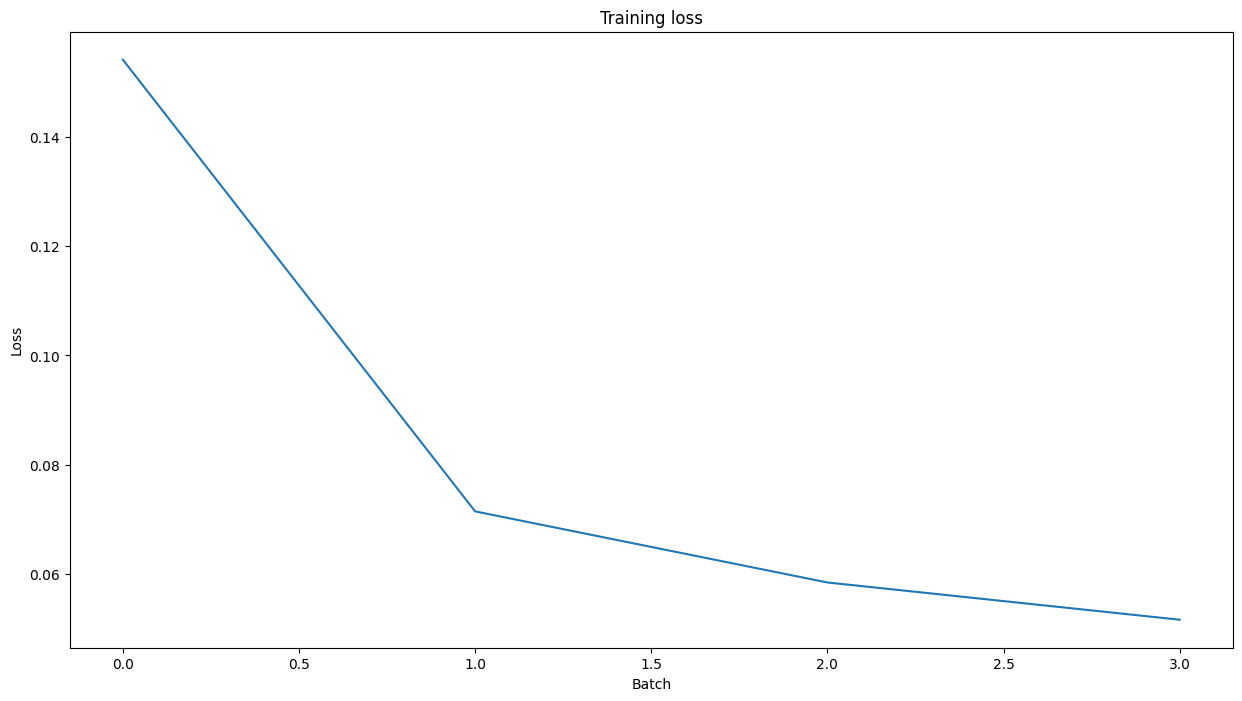

In [98]:
plt.figure(figsize=(15,8))
plt.title("Training loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.plot(train_loss_set)
plt.show()

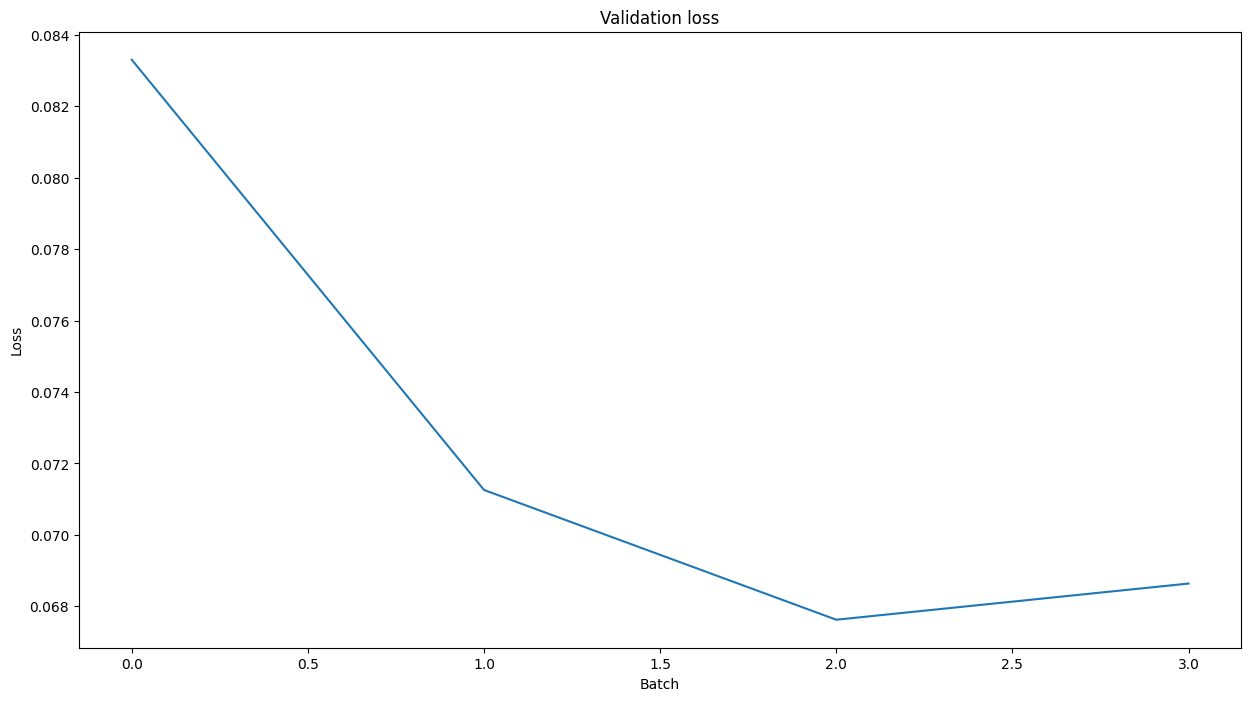

In [97]:
plt.figure(figsize=(15,8))
plt.title("Validation loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.plot(val_loss_set)
plt.show()

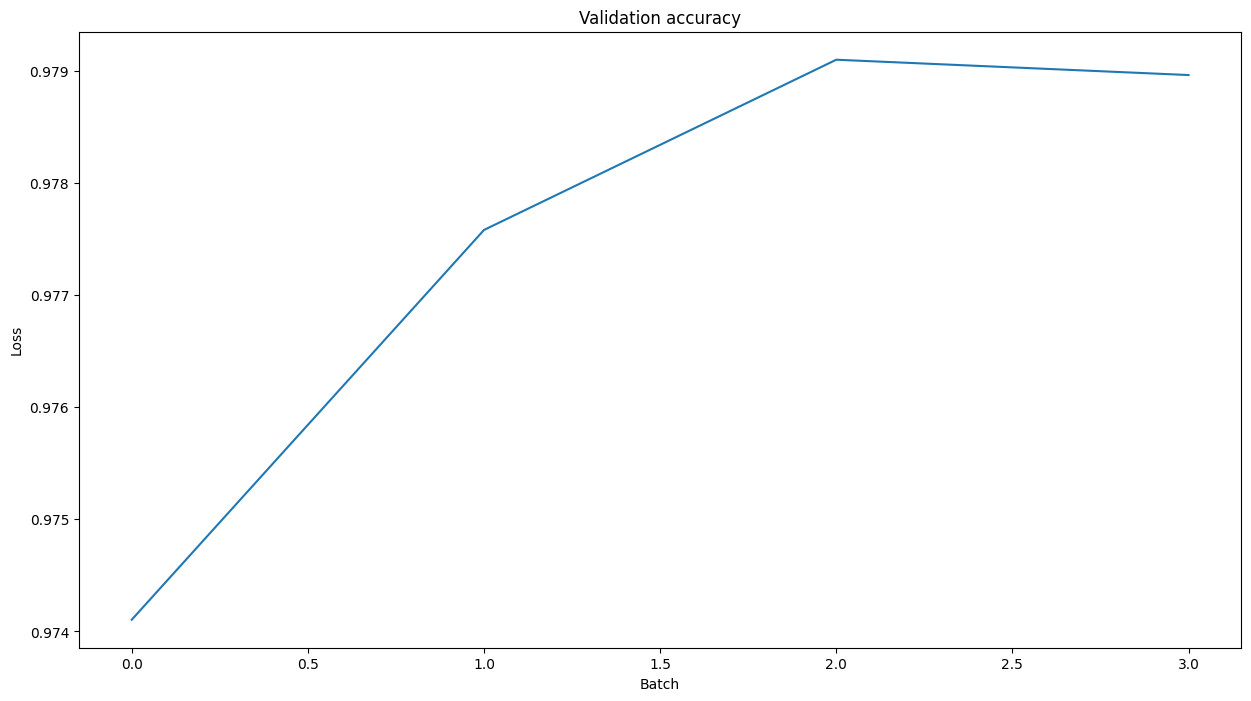

In [96]:
plt.figure(figsize=(15,8))
plt.title("Validation accuracy")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.plot(val_accuracy_set)
plt.show()

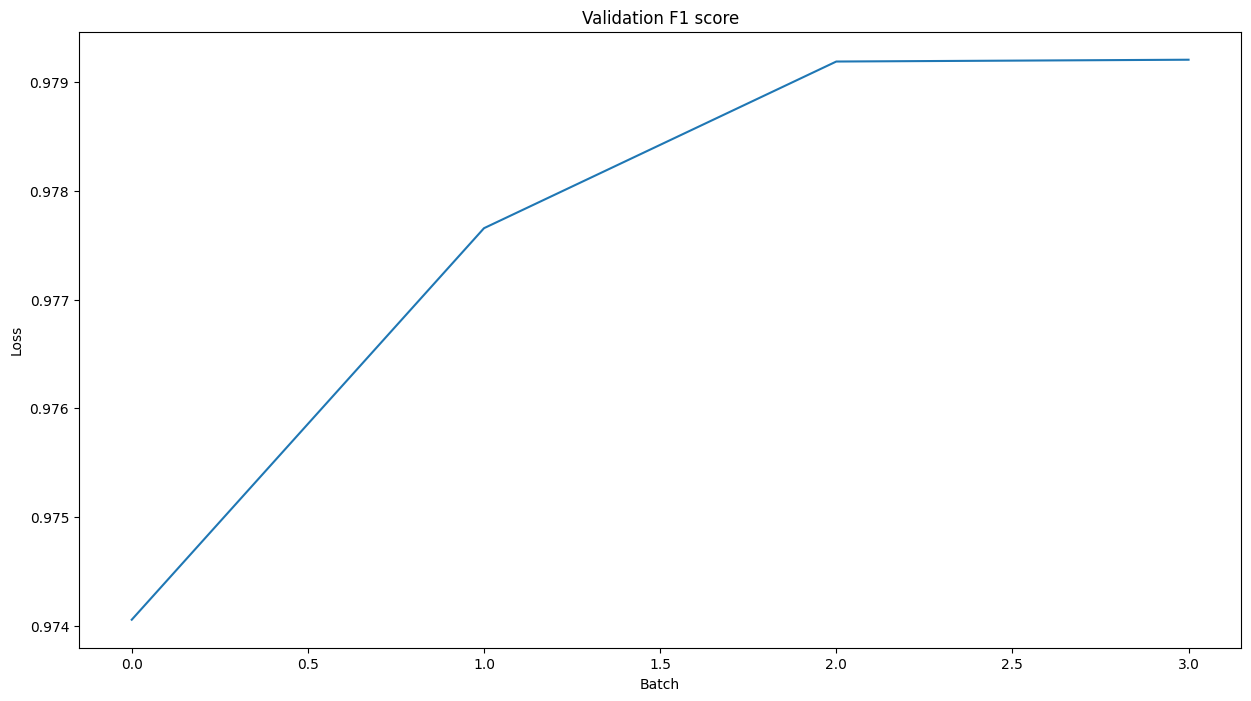

In [95]:
plt.figure(figsize=(15,8))
plt.title("Validation F1 score")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.plot(val_f1_set)
plt.show()

In [47]:
test_processed = processed["test"]

In [48]:
test_sampler = RandomSampler(test_processed)
test_dataloader = DataLoader(test_processed, sampler=test_sampler, batch_size=batch_size, collate_fn=data_collator)

In [50]:
import torch
from tqdm import tqdm

# Assicurati che il modello sia in modalità evaluation
model.eval()

# Se il modello è wrappato in DataParallel, accedi al modello base
base_model = model.module if hasattr(model, 'module') else model

# Liste per salvare i risultati
all_predictions = []
all_labels = []
all_texts = []

# Disabilita il calcolo dei gradienti per velocizzare
with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Evaluating"):
        # Sposta il batch su GPU se disponibile
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Predizione
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        # Ottieni le predizioni (argmax)
        predictions = torch.argmax(outputs.logits, dim=-1)
        
        # Salva predizioni e label (solo dove attention_mask == 1)
        for i in range(len(predictions)):
            # Maschera per ignorare padding e token speciali
            mask = (attention_mask[i] == 1) & (labels[i] != -100)
            
            pred_labels = predictions[i][mask].cpu().numpy()
            true_labels = labels[i][mask].cpu().numpy()
            
            # Converti in nomi delle label (usa base_model invece di model)
            pred_tags = [base_model.config.id2label[p] for p in pred_labels]
            true_tags = [base_model.config.id2label[l] for l in true_labels]
            
            all_predictions.append(pred_tags)
            all_labels.append(true_tags)
            
            # Decodifica il testo originale
            tokens = tok.convert_ids_to_tokens(input_ids[i][mask].cpu().numpy())
            all_texts.append(tokens)

print(f"Processati {len(all_predictions)} esempi")

Evaluating: 100%|██████████| 175/175 [00:29<00:00,  6.03it/s]

Processati 5594 esempi


In [51]:
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

# Report completo
print(classification_report(all_labels, all_predictions))

# Metriche aggregate
print(f"\nF1 Score: {f1_score(all_labels, all_predictions):.4f}")
print(f"Precision: {precision_score(all_labels, all_predictions):.4f}")
print(f"Recall: {recall_score(all_labels, all_predictions):.4f}")

                           precision    recall  f1-score   support

              account_pin       0.68      0.69      0.68       118
                  api_key       0.84      0.80      0.82        74
      bank_routing_number       0.58      0.76      0.66       126
                     bban       0.82      0.93      0.87       135
                  company       0.73      0.88      0.80      4834
       credit_card_number       0.64      0.86      0.73        93
credit_card_security_code       0.80      0.64      0.71       105
              customer_id       0.57      0.80      0.67       171
                     date       0.74      0.84      0.79      6208
            date_of_birth       0.70      0.94      0.80       232
                date_time       0.37      0.44      0.40        77
    driver_license_number       0.68      0.84      0.75       108
                    email       0.82      0.92      0.87      1080
              employee_id       0.61      0.68      0.65     

In [59]:
def censor_text_from_predictions(tokens, pred_tags, tokenizer):
    """
    Ricostruisce il testo censurado basandosi sulle predizioni
    """
    censored_tokens = []
    
    for token, tag in zip(tokens, pred_tags):
        if tag != 'O':  # Se è un'entità PII
            # Censura il token
            if token.startswith('##'):
                censored_tokens.append('##' + '█' * (len(token) - 2))
            else:
                censored_tokens.append('█' * len(token))
        else:
            censored_tokens.append(token)
    
    # Ricostruisci la frase
    censored_text = tokenizer.convert_tokens_to_string(censored_tokens)
    return censored_text

In [88]:
import random

n = random.randint(0,len(all_texts))

original = tok.convert_tokens_to_string(all_texts[n])
censored = censor_text_from_predictions(all_texts[n], all_predictions[n], tok)

print(f"\nExample {n+1}:")
print(f"Original:\n{original}")
print(f"Censored:\n{censored}")
print(f"Entities:\n{[tag for tag in all_predictions[n] if tag != 'O']}")


Example 1195:
Original:
**Loan Application - Individual Details** **Applicant Name:** Anna Svensson **Date of Birth:** 15/03/1985 **Gender:** Kvinna (Female) **Contact Information** * Address: Södra Larmgatan 3, 411 17 Göteborg * Phone: 070-123 45 67 * Email: [anna.svensson@email.com](mailto:anna.svensson@email.com) **Employment Details** * Employer: Volvo Cars * Position: Ingenjör (Engineer) * Annual Income: 550 000 SEK * Employment Duration: 6 år (6 years) **Financial Details** * Loan Amount: 800 000 SEK * Loan Purpose: Bostad (Housing) **Supporting Documents** * Copy of ID * Payslips for the last 3 months * Bank statements for the last 6 months * Employment contract * Income tax return for the last 2 years
Censored:
**Loan Application - Individual Details** **Applicant Name:**██████████████ **Date of Birth:**███████████ **Gender:** Kvinna (Female) **Contact Information** * Address:███████████████████████████████████ * Phone:██████████████ * Email: [███████████████████████](mailto:█